### Configuración del Entorno

In [2]:
# Importación de librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración para reproducibilidad y visualización
np.random.seed(42)
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Entorno configurado correctamente")
print(f"Versión de pandas: {pd.__version__}")
print(f"Versión de numpy: {np.__version__}")


Entorno configurado correctamente
Versión de pandas: 2.2.2
Versión de numpy: 2.0.2


### Carga del Dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from google.colab import drive
drive.mount('/content/drive')

# Two datasets with hotel demand data. One of the hotels (H1) is a resort hotel and the other is a city hotel (H2).
# Both datasets share the same structure, with 31 variables describing the 40,060 observations of H1 and 79,330 observations of H2.
# Both datasets comprehend bookings due to arrive between the 1st of July of 2015 and the 31st of August 2017, including bookings that effectively
# arrived and bookings that were canceled

h1_path = '/content/drive/MyDrive/TFM/H1.csv'
h2_path = '/content/drive/MyDrive/TFM/H2.csv'

h1 = pd.read_csv(h1_path)
h2 = pd.read_csv(h2_path)

# Añadir la columna 'Tipo_Hotel' para diferenciar el mercado
h1['Tipo_Hotel'] = 'Resort'
h2['Tipo_Hotel'] = 'City'


Mounted at /content/drive


In [4]:
h1.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,Meal,Country,MarketSegment,DistributionChannel,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,ReservedRoomType,AssignedRoomType,BookingChanges,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,Tipo_Hotel
0,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01,Resort
1,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01,Resort
2,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02,Resort
3,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02,Resort
4,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03,Resort


In [5]:
h2.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,Meal,Country,MarketSegment,DistributionChannel,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,ReservedRoomType,AssignedRoomType,BookingChanges,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,Tipo_Hotel
0,0,6,2015,July,27,1,0,2,1,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,6,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-03,City
1,1,88,2015,July,27,1,0,4,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9,NULL,0,Transient,76.5,0,1,Canceled,2015-07-01,City
2,1,65,2015,July,27,1,0,4,1,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9,NULL,0,Transient,68.0,0,1,Canceled,2015-04-30,City
3,1,92,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9,NULL,0,Transient,76.5,0,2,Canceled,2015-06-23,City
4,1,100,2015,July,27,2,0,2,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9,NULL,0,Transient,76.5,0,1,Canceled,2015-04-02,City


# Adquisición y Comprensión de los Datos

In [6]:
# Concatenar ambos DataFrames en uno solo maestro
# ignore_index=True reasigna los índices para que vayan del 0 al 119389 sin repetirse
df_hotel = pd.concat([h1, h2], ignore_index=True)

# Eliminar las variables que causan fuga de datos (Data Leakage)
# Estas columnas revelan si el cliente canceló o hizo check-out, algo que el modelo no debe saber al predecir
columnas_fuga = ['ReservationStatus', 'ReservationStatusDate']
df_hotel = df_hotel.drop(columns=columnas_fuga)

# Verificación de los resultados
print("Dimensiones del DataFrame consolidado:", df_hotel.shape)
print("\nVariables actuales en el DataFrame:")
print(df_hotel.columns.tolist())


Dimensiones del DataFrame consolidado: (119390, 30)

Variables actuales en el DataFrame:
['IsCanceled', 'LeadTime', 'ArrivalDateYear', 'ArrivalDateMonth', 'ArrivalDateWeekNumber', 'ArrivalDateDayOfMonth', 'StaysInWeekendNights', 'StaysInWeekNights', 'Adults', 'Children', 'Babies', 'Meal', 'Country', 'MarketSegment', 'DistributionChannel', 'IsRepeatedGuest', 'PreviousCancellations', 'PreviousBookingsNotCanceled', 'ReservedRoomType', 'AssignedRoomType', 'BookingChanges', 'DepositType', 'Agent', 'Company', 'DaysInWaitingList', 'CustomerType', 'ADR', 'RequiredCarParkingSpaces', 'TotalOfSpecialRequests', 'Tipo_Hotel']


In [7]:
# Vista previa de las primeras filas para confirmar la nueva columna 'Tipo_Hotel'
display(df_hotel.head())

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,Meal,Country,MarketSegment,DistributionChannel,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,ReservedRoomType,AssignedRoomType,BookingChanges,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,Tipo_Hotel
0,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Resort
1,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Resort
2,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Resort
3,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,NULL,0,Transient,75.0,0,0,Resort
4,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,NULL,0,Transient,98.0,0,1,Resort


In [8]:
# 1. Filtrar las reservas que SÍ se cancelaron y que contaban con política flexible/reembolsable
canceladas_reembolsables = df_hotel[(df_hotel['IsCanceled'] == 1) & (df_hotel['DepositType'] != 'Non Refund')].copy()

# 2. Calcular la suma total de noches combinando días de semana y fines de semana
canceladas_reembolsables['total_nights'] = canceladas_reembolsables['StaysInWeekendNights'] + canceladas_reembolsables['StaysInWeekNights']

# 3. Calcular la pérdida total acumulada multiplicando el ADR por el total de noches calculadas
perdida_resort = (canceladas_reembolsables[canceladas_reembolsables['Tipo_Hotel'] == 'Resort']['ADR'] * canceladas_reembolsables[canceladas_reembolsables['Tipo_Hotel'] == 'Resort']['total_nights']).sum()
perdida_city = (canceladas_reembolsables[canceladas_reembolsables['Tipo_Hotel'] == 'City']['ADR'] * canceladas_reembolsables[canceladas_reembolsables['Tipo_Hotel'] == 'City']['total_nights']).sum()

print(f"Pérdida total histórica Resort Hotel: {perdida_resort:,.2f}")
print(f"Pérdida total histórica City Hotel: {perdida_city:,.2f}")

Pérdida total histórica Resort Hotel: 5,842,177.34
Pérdida total histórica City Hotel: 10,885,059.78


In [9]:
# Identificación de estructura, tipos de variables y rangos

print("=== ESTRUCTURA DEL CONJUNTO DE DATOS ===")
print(f"Total de observaciones (reservas): {df_hotel.shape[0]}")
print(f"Total de variables (características): {df_hotel.shape[1]}\n")

# Revisión de los tipos de datos y valores no nulos iniciales
print("=== INFORMACIÓN DE VARIABLES Y TIPOS DE DATOS ===")
df_hotel.info()

# Resumen estadístico descriptivo (rangos, medias, desviación estándar)
print("\n=== RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ===")
resumen_estadistico = df_hotel.describe().T
display(resumen_estadistico)

=== ESTRUCTURA DEL CONJUNTO DE DATOS ===
Total de observaciones (reservas): 119390
Total de variables (características): 30

=== INFORMACIÓN DE VARIABLES Y TIPOS DE DATOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   IsCanceled                   119390 non-null  int64  
 1   LeadTime                     119390 non-null  int64  
 2   ArrivalDateYear              119390 non-null  int64  
 3   ArrivalDateMonth             119390 non-null  object 
 4   ArrivalDateWeekNumber        119390 non-null  int64  
 5   ArrivalDateDayOfMonth        119390 non-null  int64  
 6   StaysInWeekendNights         119390 non-null  int64  
 7   StaysInWeekNights            119390 non-null  int64  
 8   Adults                       119390 non-null  int64  
 9   Children                     119386 non-null  float64
 10  B

,count,mean,std,min,25%,50%,75%,max
IsCanceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
LeadTime,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
ArrivalDateYear,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
ArrivalDateWeekNumber,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
ArrivalDateDayOfMonth,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
StaysInWeekendNights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
StaysInWeekNights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
Adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
Children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
Babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [10]:
df_hotel.isna().sum()


,0
IsCanceled,0
LeadTime,0
ArrivalDateYear,0
ArrivalDateMonth,0
ArrivalDateWeekNumber,0
ArrivalDateDayOfMonth,0
StaysInWeekendNights,0
StaysInWeekNights,0
Adults,0
Children,4


### Evaluación del Desbalanceo de Clases y Análisis por Tipología de Hotel




=== DESBALANCEO DE LA VARIABLE OBJETIVO (IsCanceled) ===
Distribución Global (%):
 IsCanceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

Tasa de Cancelación por Tipo de Hotel:
Tipo_Hotel  IsCanceled
City        0             58.273037
            1             41.726963
Resort      0             72.236645
            1             27.763355
Name: proportion, dtype: float64


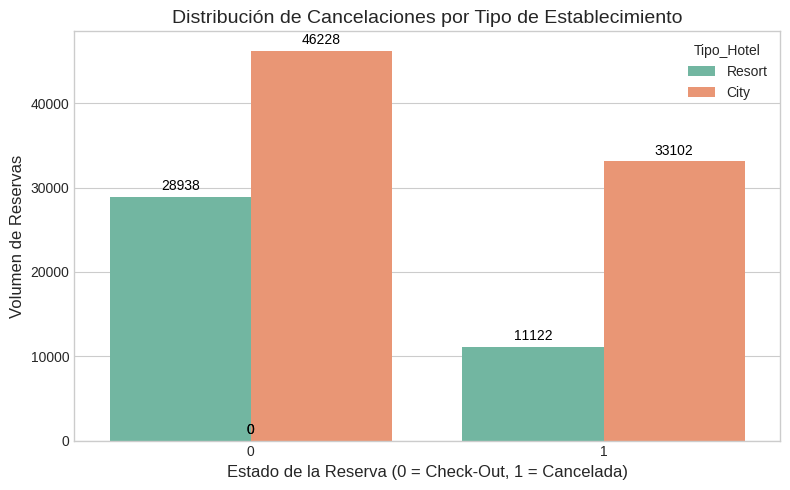

In [11]:
### Evaluación del desbalance de la variable objetivo

print("\n=== DESBALANCEO DE LA VARIABLE OBJETIVO (IsCanceled) ===")

distribucion_global = df_hotel['IsCanceled'].value_counts(normalize=True) * 100
print("Distribución Global (%):\n", distribucion_global)

print("\nTasa de Cancelación por Tipo de Hotel:")
print(df_hotel.groupby('Tipo_Hotel')['IsCanceled'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_hotel, x='IsCanceled', hue='Tipo_Hotel', palette='Set2')
plt.title('Distribución de Cancelaciones por Tipo de Establecimiento', fontsize=14)
plt.xlabel('Estado de la Reserva (0 = Check-Out, 1 = Cancelada)', fontsize=12)
plt.ylabel('Volumen de Reservas', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### PREPARACIÓN Y LIMPIEZA DE DATOS

In [12]:
import pandas as pd
import numpy as np

print("=== PREPARACIÓN Y LIMPIEZA DE DATOS ===")
dimensiones_originales = df_hotel.shape

# ---------------------------------------------------------
# TRATAMIENTO DE NULOS
# ---------------------------------------------------------
# Las columnas Agent y Company tienen la palabra "NULL" como texto.
# Transformamos esto en variables binarias: 1 si usó agencia/empresa, 0 si no.

df_hotel['Tiene_Agencia'] = np.where(df_hotel['Agent'].astype(str).str.contains('NULL'), 0, 1)
df_hotel['Tiene_Empresa'] = np.where(df_hotel['Company'].astype(str).str.contains('NULL'), 0, 1)

df_hotel = df_hotel.copy().drop(columns=['Agent', 'Company'],errors='ignore')

# Imputación de nulos reales (NaN) detectados
df_hotel['Country'] = df_hotel['Country'].fillna('Unknown')
df_hotel['Children'] = df_hotel['Children'].fillna(0)

df_hotel.head()

=== PREPARACIÓN Y LIMPIEZA DE DATOS ===


,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,Meal,Country,MarketSegment,DistributionChannel,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,ReservedRoomType,AssignedRoomType,BookingChanges,DepositType,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,Tipo_Hotel,Tiene_Agencia,Tiene_Empresa
0,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.0,0,0,Resort,0,0
1,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.0,0,0,Resort,0,0
2,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.0,0,0,Resort,0,0
3,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.0,0,0,Resort,1,0
4,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.0,0,1,Resort,1,0


In [13]:
# ---------------------------------------------------------
# TRATAMIENTO DE VALORES ATÍPICOS (OUTLIERS)
# ---------------------------------------------------------
# Eliminamos reservas que son operativamente imposibles o erróneas en el PMS
filtro_outliers = (
    (df_hotel['Adults'] + df_hotel['Children'] + df_hotel['Babies'] == 0) | # 0 huéspedes
    (df_hotel['StaysInWeekendNights'] + df_hotel['StaysInWeekNights'] == 0) | # 0 noches
    (df_hotel['ADR'] < 0) # Tarifa diaria negativa
)

df_hotel = df_hotel[~filtro_outliers]

print(f"Registros eliminados por anomalías: {dimensiones_originales[0] - df_hotel.shape[0]}")
print(f"Nuevas dimensiones tras limpieza: {df_hotel.shape}")

Registros eliminados por anomalías: 826
Nuevas dimensiones tras limpieza: (118564, 30)


In [14]:
# ---------------------------------------------------------
# INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)
# ---------------------------------------------------------
# Consolidar el volumen total de la reserva
df_hotel['Total_Huespedes'] = df_hotel['Adults'] + df_hotel['Children'] + df_hotel['Babies']
df_hotel['Total_Noches'] = df_hotel['StaysInWeekendNights'] + df_hotel['StaysInWeekNights']

# Reducir la altísima cardinalidad de la columna 'Country'
# Agruparemos los países con menos de 100 reservas históricas en una categoría "Other"
conteo_paises = df_hotel['Country'].value_counts()
paises_frecuentes = conteo_paises[conteo_paises >= 100].index
df_hotel['Country'] = df_hotel['Country'].apply(lambda x: x if x in paises_frecuentes else 'Other')

# Eliminamos variables que causan Fuga de Datos (Data Leakage)
# (Estas variables revelan el futuro de la reserva y arruinan la predicción)
columnas_fuga = ['ReservationStatus', 'ReservationStatusDate']
df_hotel = df_hotel.drop(columns=columnas_fuga, errors='ignore')

# ---------------------------------------------------------
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ---------------------------------------------------------
# Seleccionar todas las columnas tipo 'object' (texto)
vars_categoricas = df_hotel.select_dtypes(include=['object']).columns.tolist()

# Aplicar One-Hot Encoding
# Usamos drop_first=True para evitar el problema de la multicolinealidad perfecta
df_model = pd.get_dummies(df_hotel, columns=vars_categoricas, drop_first=True)

print(f"Dimensiones tras Feature Engineering y Codificación: {df_model.shape}")

Dimensiones tras Feature Engineering y Codificación: (118564, 111)


### División del conjunto de datos


In [15]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# ---------------------------------------------------------
# DIVISIÓN DEL CONJUNTO DE DATOS (TRAIN / TEST)
# ---------------------------------------------------------
# Separar características (X) y variable objetivo (y)
# Identificar la columna que diferencia los hoteles tras el One-Hot Encoding
# Generalmente get_dummies crea 'Tipo_Hotel_Resort' o 'Tipo_Hotel_City'

columna_tipo = [col for col in df_model.columns if 'Tipo_Hotel' in col][0]

# Separar los DataFrames
if 'Resort' in columna_tipo:
    df_resort = df_model[df_model[columna_tipo] == 1].drop(columns=[columna_tipo])
    df_city = df_model[df_model[columna_tipo] == 0].drop(columns=[columna_tipo])
else:
    df_city = df_model[df_model[columna_tipo] == 1].drop(columns=[columna_tipo])
    df_resort = df_model[df_model[columna_tipo] == 0].drop(columns=[columna_tipo])

print(f"Dimensiones Hotel Resort: {df_resort.shape}")
print(f"Dimensiones City Hotel: {df_city.shape}")

# Separar características (X) y variable objetivo (y) para cada uno
X_resort = df_resort.drop(columns=['IsCanceled'])
y_resort = df_resort['IsCanceled']

X_city = df_city.drop(columns=['IsCanceled'])
y_city = df_city['IsCanceled']


Dimensiones Hotel Resort: (39665, 110)
Dimensiones City Hotel: (78899, 110)


### Aplicación de SMOTE

In [16]:
print("=== DIVISIÓN TRAIN/TEST Y SMOTE POR HOTEL ===")

smote = SMOTE(random_state=42)

# --- RESORT HOTEL ---
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(
    X_resort, y_resort, test_size=0.30, random_state=42, stratify=y_resort
)
X_train_res_smote, y_train_res_smote = smote.fit_resample(X_train_res, y_train_res)

print("\n--- RESORT HOTEL ---")
print("Train SMOTE (y):", np.bincount(y_train_res_smote))
print("Test (y - Desbalanceo Real):", np.bincount(y_test_res))

# --- CITY HOTEL ---
X_train_cit, X_test_cit, y_train_cit, y_test_cit = train_test_split(
    X_city, y_city, test_size=0.30, random_state=42, stratify=y_city
)
X_train_cit_smote, y_train_cit_smote = smote.fit_resample(X_train_cit, y_train_cit)

print("\n--- CITY HOTEL ---")
print("Train SMOTE (y):", np.bincount(y_train_cit_smote))
print("Test (y - Desbalanceo Real):", np.bincount(y_test_cit))

=== DIVISIÓN TRAIN/TEST Y SMOTE POR HOTEL ===

--- RESORT HOTEL ---
Train SMOTE (y): [19988 19988]
Test (y - Desbalanceo Real): [8567 3333]

--- CITY HOTEL ---
Train SMOTE (y): [32083 32083]
Test (y - Desbalanceo Real): [13750  9920]


### Análisis Bivariado


=== ANÁLISIS EXPLORATORIO DE DATOS (EDA) ===


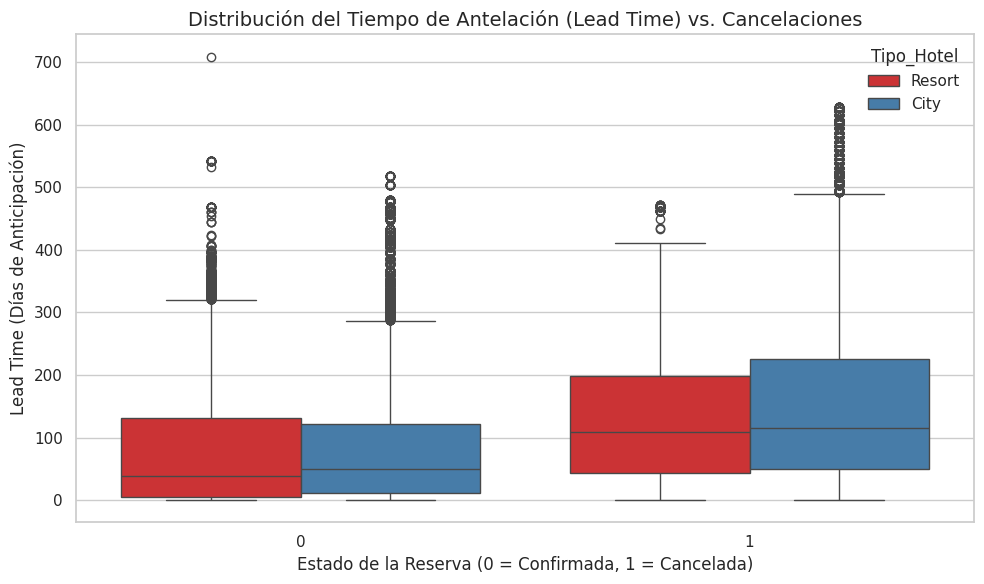

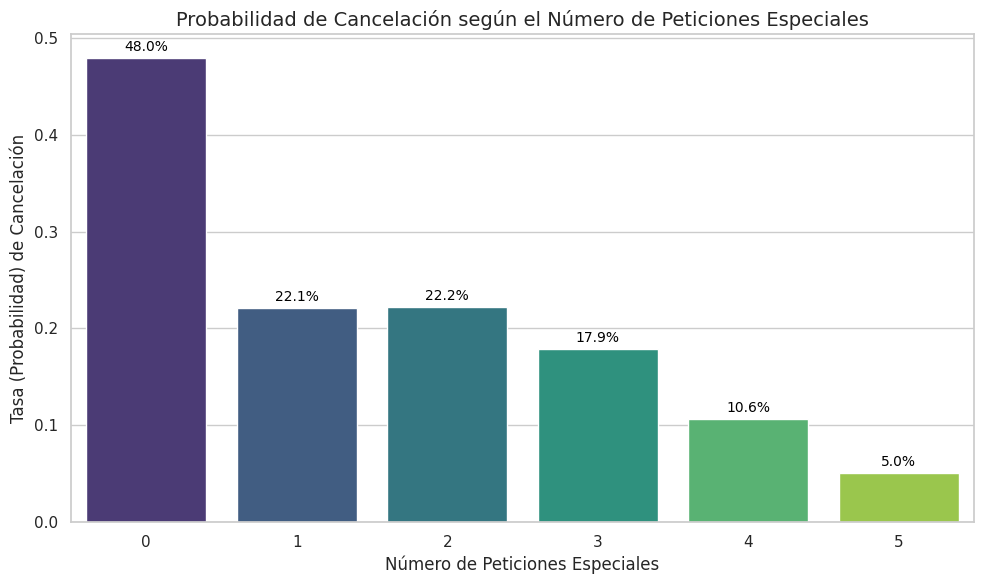

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=== ANÁLISIS EXPLORATORIO DE DATOS (EDA) ===")

sns.set_theme(style="whitegrid")

# Impacto del Lead Time sobre las Cancelaciones
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_hotel, x='IsCanceled', y='LeadTime', hue='Tipo_Hotel', palette='Set1')
plt.title('Distribución del Tiempo de Antelación (Lead Time) vs. Cancelaciones', fontsize=14)
plt.xlabel('Estado de la Reserva (0 = Confirmada, 1 = Cancelada)', fontsize=12)
plt.ylabel('Lead Time (Días de Anticipación)', fontsize=12)
plt.tight_layout()
plt.show()

# Impacto de las Peticiones Especiales
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_hotel, x='TotalOfSpecialRequests', y='IsCanceled', errorbar=None, palette='viridis')
plt.title('Probabilidad de Cancelación según el Número de Peticiones Especiales', fontsize=14)
plt.xlabel('Número de Peticiones Especiales', fontsize=12)
plt.ylabel('Tasa (Probabilidad) de Cancelación', fontsize=12)

# Añadir porcentajes a las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()


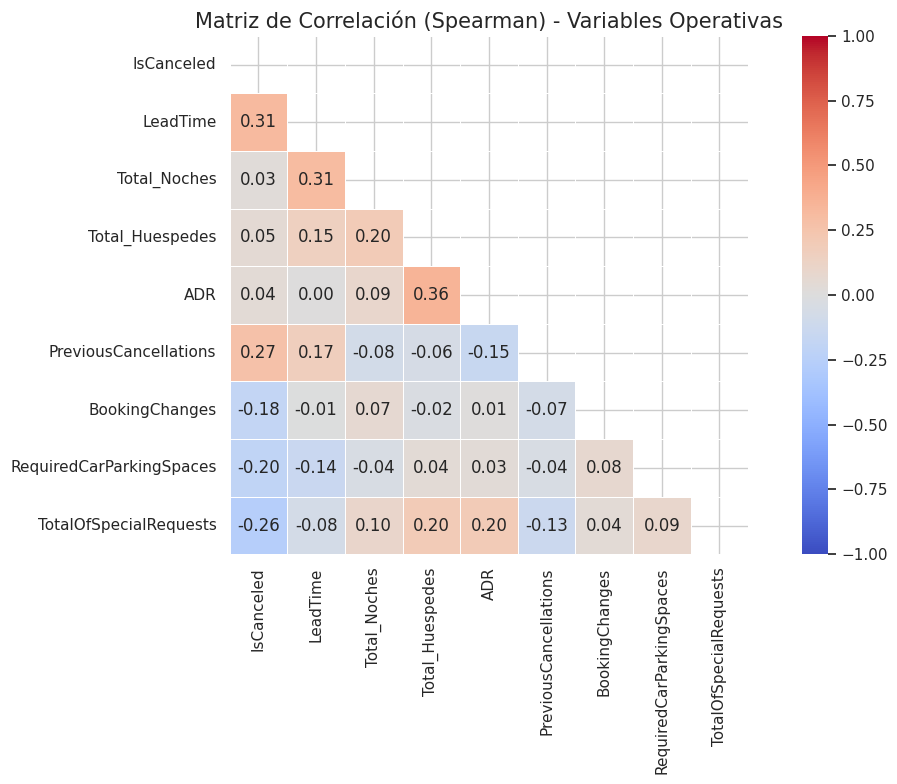

In [18]:
# =====================================================================
# Identificación de Correlaciones Latentes (Matriz Multivariada)
# =====================================================================

# Seleccionar solo las variables numéricas más relevantes para el heatmap
vars_numericas = ['IsCanceled', 'LeadTime', 'Total_Noches', 'Total_Huespedes',
                  'ADR', 'PreviousCancellations', 'BookingChanges',
                  'RequiredCarParkingSpaces', 'TotalOfSpecialRequests']

matriz_corr = df_hotel[vars_numericas].corr(method='spearman')

# Generar el Heatmap de Correlación
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', mask=mask,
            vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Matriz de Correlación (Spearman) - Variables Operativas', fontsize=15)
plt.tight_layout()
plt.show()

# Aprendizaje no supervisado: K-Means

=== FASE 5.1.A: PCA COMPARATIVO (RESORT VS. CITY HOTEL) ===

Resultados para Resort Hotel:
- Componentes para retener el 80% de varianza: 62
- Componentes para retener el 90% de varianza: 74
- Reducción dimensional al 80%: 43.12% de variables eliminadas.

Resultados para City Hotel:
- Componentes para retener el 80% de varianza: 61
- Componentes para retener el 90% de varianza: 72
- Reducción dimensional al 80%: 44.04% de variables eliminadas.


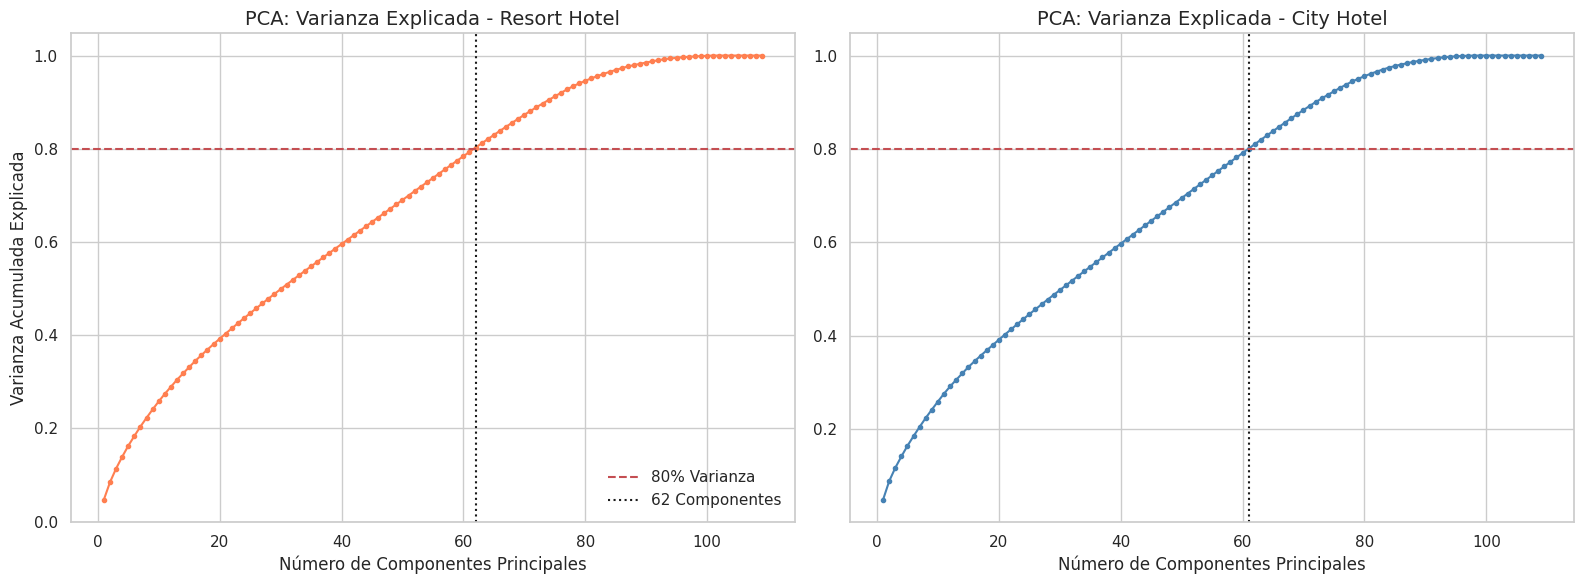

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("=== FASE 5.1.A: PCA COMPARATIVO (RESORT VS. CITY HOTEL) ===")

def ejecutar_pca_hotel(X_data, nombre_hotel):
    # 1. Estandarización
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_data)

    # 2. PCA sin límite para ver la varianza total
    pca_full = PCA(random_state=42)
    pca_full.fit(X_scaled)

    # 3. Calcular varianza acumulada
    varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

    # 4. Calcular componentes para el 80% y 90%
    comp_80 = np.argmax(varianza_acumulada >= 0.80) + 1
    comp_90 = np.argmax(varianza_acumulada >= 0.90) + 1

    print(f"\nResultados para {nombre_hotel}:")
    print(f"- Componentes para retener el 80% de varianza: {comp_80}")
    print(f"- Componentes para retener el 90% de varianza: {comp_90}")
    print(f"- Reducción dimensional al 80%: {((X_data.shape[1] - comp_80) / X_data.shape[1]) * 100:.2f}% de variables eliminadas.")

    return varianza_acumulada, comp_80

# Ejecutar la función para ambos hoteles
var_resort, comp_80_resort = ejecutar_pca_hotel(X_resort, "Resort Hotel")
var_city, comp_80_city = ejecutar_pca_hotel(X_city, "City Hotel")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica Resort
ax1.plot(range(1, len(var_resort) + 1), var_resort, marker='.', linestyle='-', color='coral')
ax1.axhline(y=0.80, color='r', linestyle='--', label='80% Varianza')
ax1.axvline(x=comp_80_resort, color='k', linestyle=':', label=f'{comp_80_resort} Componentes')
ax1.set_title('PCA: Varianza Explicada - Resort Hotel', fontsize=14)
ax1.set_xlabel('Número de Componentes Principales', fontsize=12)
ax1.set_ylabel('Varianza Acumulada Explicada', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(True)

# Gráfica City
ax2.plot(range(1, len(var_city) + 1), var_city, marker='.', linestyle='-', color='steelblue')
ax2.axhline(y=0.80, color='r', linestyle='--', label='80% Varianza')
ax2.axvline(x=comp_80_city, color='k', linestyle=':', label=f'{comp_80_city} Componentes')
ax2.set_title('PCA: Varianza Explicada - City Hotel', fontsize=14)
ax2.set_xlabel('Número de Componentes Principales', fontsize=12)
ax2.grid(True)

plt.tight_layout()
plt.show()

=== OPTIMIZACIÓN DE CLÚSTERES (K) POR HOTEL ===

Procesando Resort Hotel...

Procesando City Hotel...


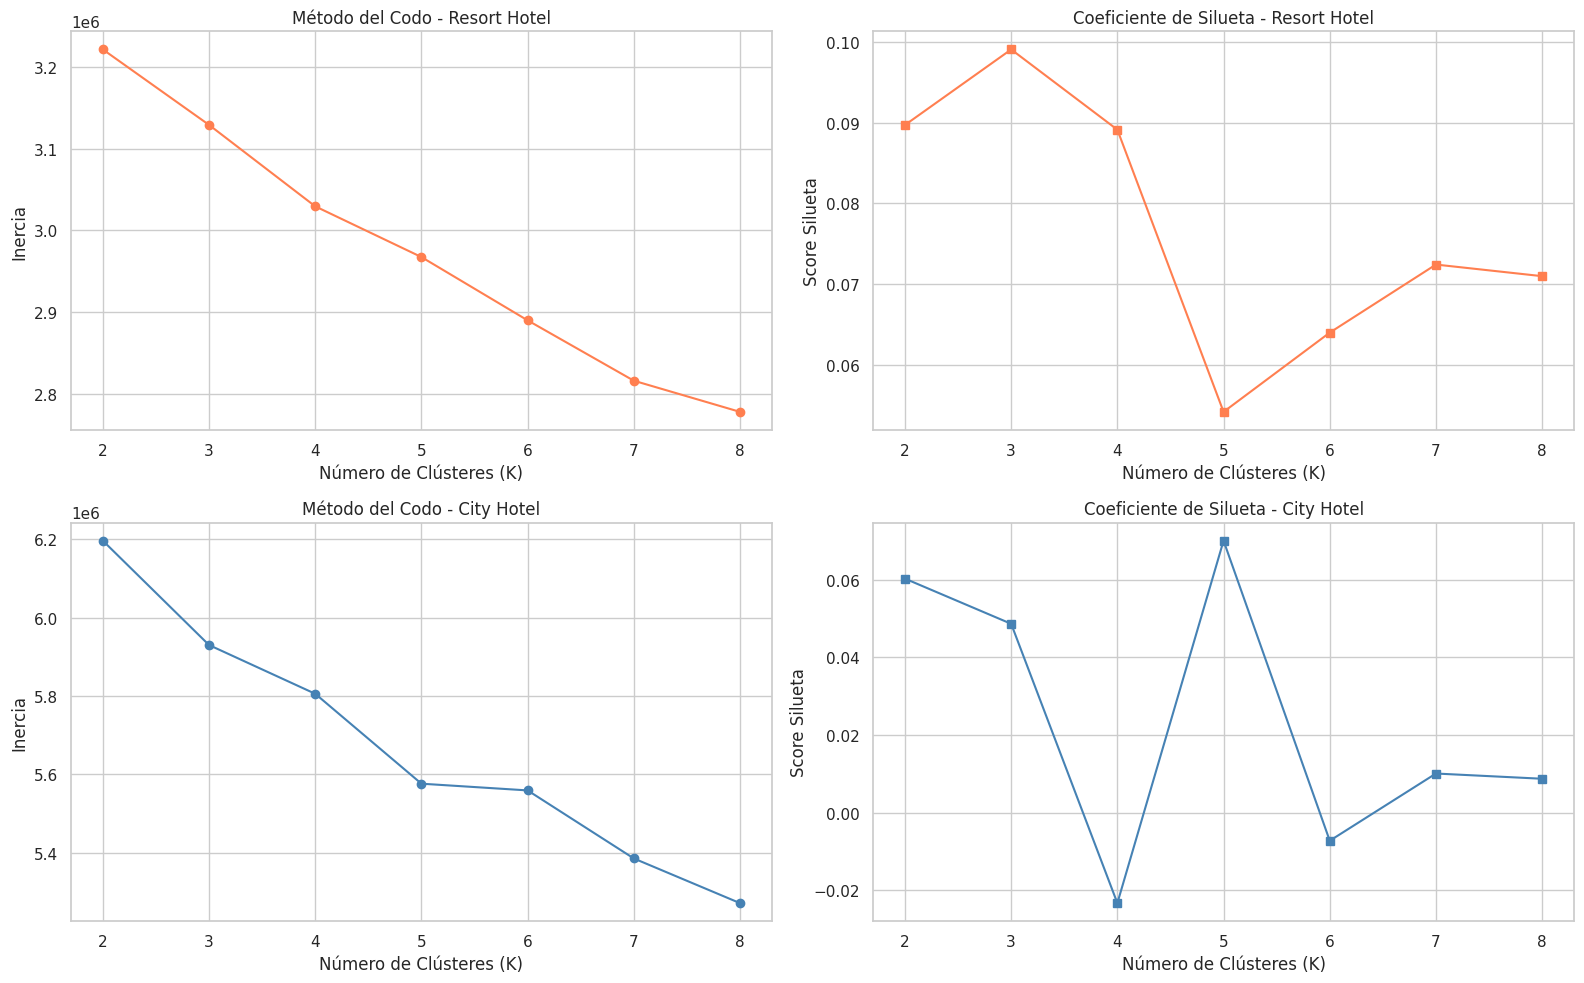


Resort Hotel - K óptimo (mayor silueta): 3
City Hotel - K óptimo (mayor silueta): 5


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("=== OPTIMIZACIÓN DE CLÚSTERES (K) POR HOTEL ===")

def analizar_codo_silueta(X_data, n_componentes, nombre_hotel):
    print(f"\nProcesando {nombre_hotel}...")
    # 1. Preparar datos con PCA óptimo
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_data)
    pca = PCA(n_components=n_componentes, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    inercias = []
    siluetas = []
    rango_k = range(2, 9) # Evaluamos de 2 a 8 clústeres

    np.random.seed(42)
    indices_sil = np.random.choice(X_pca.shape[0], size=min(10000, X_pca.shape[0]), replace=False)
    X_pca_sample = X_pca[indices_sil]

    for k in rango_k:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_pca)

        inercias.append(kmeans.inertia_)

        etiquetas_muestra = kmeans.predict(X_pca_sample)
        siluetas.append(silhouette_score(X_pca_sample, etiquetas_muestra))

    return rango_k, inercias, siluetas

# Ejecutar para ambos hoteles usando sus componentes óptimos
k_resort, inercias_res, siluetas_res = analizar_codo_silueta(X_resort, 62, "Resort Hotel")
k_city, inercias_cit, siluetas_cit = analizar_codo_silueta(X_city, 61, "City Hotel")


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Resort - Codo
axes[0,0].plot(k_resort, inercias_res, marker='o', color='coral')
axes[0,0].set_title('Método del Codo - Resort Hotel')
axes[0,0].set_xlabel('Número de Clústeres (K)')
axes[0,0].set_ylabel('Inercia')
axes[0,0].grid(True)

# Resort - Silueta
axes[0,1].plot(k_resort, siluetas_res, marker='s', color='coral')
axes[0,1].set_title('Coeficiente de Silueta - Resort Hotel')
axes[0,1].set_xlabel('Número de Clústeres (K)')
axes[0,1].set_ylabel('Score Silueta')
axes[0,1].grid(True)

# City - Codo
axes[1,0].plot(k_city, inercias_cit, marker='o', color='steelblue')
axes[1,0].set_title('Método del Codo - City Hotel')
axes[1,0].set_xlabel('Número de Clústeres (K)')
axes[1,0].set_ylabel('Inercia')
axes[1,0].grid(True)

# City - Silueta
axes[1,1].plot(k_city, siluetas_cit, marker='s', color='steelblue')
axes[1,1].set_title('Coeficiente de Silueta - City Hotel')
axes[1,1].set_xlabel('Número de Clústeres (K)')
axes[1,1].set_ylabel('Score Silueta')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nResort Hotel - K óptimo (mayor silueta): {k_resort[np.argmax(siluetas_res)]}")
print(f"City Hotel - K óptimo (mayor silueta): {k_city[np.argmax(siluetas_cit)]}")

In [21]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("=== PERFILADO FINAL DE CLÚSTERES (K-MEANS) ===")

def perfilar_clusters(X_data, df_original, n_comp, k_optimo, nombre_hotel):
    # 1. Pipeline PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_data)
    pca = PCA(n_components=n_comp, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    # 2. Entrenar K-Means con el K óptimo
    kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(X_pca)

    # 3. Pegar las etiquetas al dataset original (SIN escalar, para ver datos reales)
    # Usamos variables de negocio clave para el perfilado
    vars_perfil = ['LeadTime', 'ADR', 'Total_Huespedes', 'Total_Noches', 'TotalOfSpecialRequests', 'IsCanceled']

    # Recuperamos las filas exactas del DataFrame original usando el índice
    df_perfil = df_hotel.loc[X_data.index, vars_perfil].copy()
    df_perfil['Cluster'] = etiquetas

    # 4. Agrupar y sacar promedios
    perfil_resumen = df_perfil.groupby('Cluster').mean().round(2)

    # Contar tamaño del cluster
    perfil_resumen['%_Total_Clientes'] = (df_perfil['Cluster'].value_counts(normalize=True) * 100).round(1)

    print(f"\n--- PERFIL DE CLIENTES: {nombre_hotel.upper()} (K={k_optimo}) ---")
    print(perfil_resumen)
    return perfil_resumen

# Ejecutar usando los hiperparámetros óptimos que encontramos
perfil_resort = perfilar_clusters(X_resort, df_hotel, n_comp=62, k_optimo=3, nombre_hotel="Resort Hotel")
perfil_city = perfilar_clusters(X_city, df_hotel, n_comp=61, k_optimo=5, nombre_hotel="City Hotel")

=== PERFILADO FINAL DE CLÚSTERES (K-MEANS) ===

--- PERFIL DE CLIENTES: RESORT HOTEL (K=3) ---
         LeadTime     ADR  Total_Huespedes  Total_Noches  \
Cluster                                                    
0           91.21  169.08             3.63          4.62   
1           62.11   87.01             1.80          3.19   
2          105.62   95.06             2.00          4.81   

         TotalOfSpecialRequests  IsCanceled  %_Total_Clientes  
Cluster                                                        
0                          0.58        0.41               4.1  
1                          0.39        0.16              27.2  
2                          0.71        0.32              68.7  

--- PERFIL DE CLIENTES: CITY HOTEL (K=5) ---
         LeadTime     ADR  Total_Huespedes  Total_Noches  \
Cluster                                                    
0           82.11  113.88             2.06          3.34   
1           75.83  195.70             3.70          3.30  

# Aprendizaje supervisado

## Resort Hotel

=== APRENDIZAJE SUPERVISADO - RESORT HOTEL (ACTUALIZADO) ===

Entrenando modelo para RESORT: Regresión Logística (Baseline)...
Tiempo de entrenamiento: 3.01 segundos

--- Resultados Finales - Regresión Logística (Baseline) ---
ROC AUC Score: 0.9119

Reporte de Clasificación en Datos de Prueba Reales:
                precision    recall  f1-score   support

Confirmada (0)       0.89      0.90      0.90      8567
 Cancelada (1)       0.74      0.72      0.73      3333

      accuracy                           0.85     11900
     macro avg       0.82      0.81      0.81     11900
  weighted avg       0.85      0.85      0.85     11900


Entrenando modelo para RESORT: Random Forest...
Tiempo de entrenamiento: 8.56 segundos

--- Resultados Finales - Random Forest ---
ROC AUC Score: 0.9574

Reporte de Clasificación en Datos de Prueba Reales:
                precision    recall  f1-score   support

Confirmada (0)       0.93      0.93      0.93      8567
 Cancelada (1)       0.83      0.81    

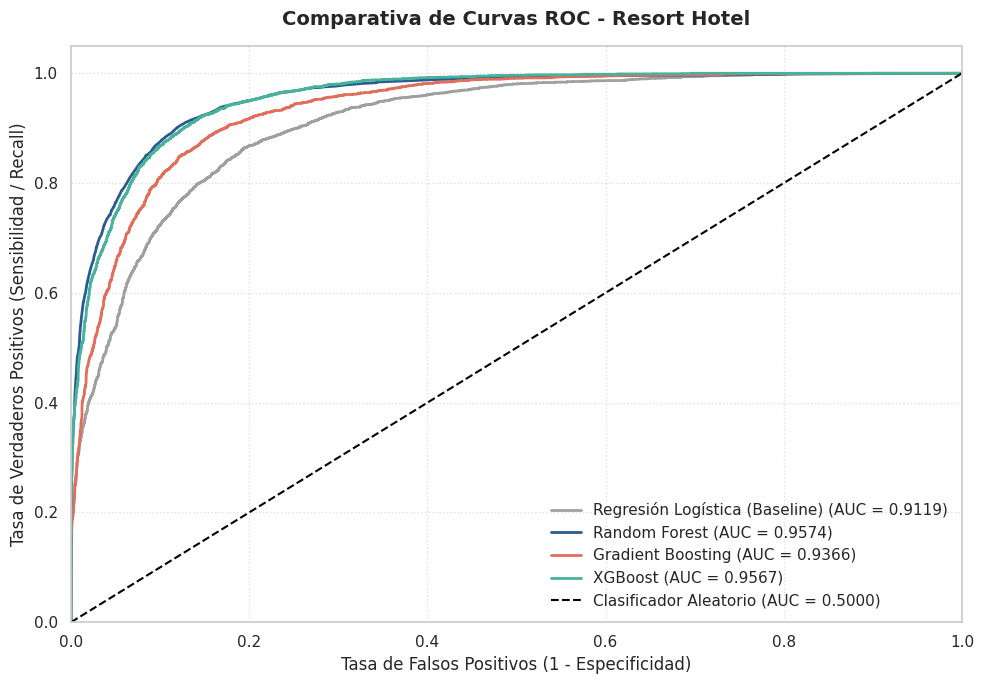


[INFO] Gráfica de curvas ROC guardada con éxito como 'curvas_roc_resort.png'


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time

print("=== APRENDIZAJE SUPERVISADO - RESORT HOTEL (ACTUALIZADO) ===")

# 1. Estandarización exclusiva para el Resort
scaler_res = StandardScaler()
X_train_res_scaled = scaler_res.fit_transform(X_train_res_smote)
X_test_res_scaled = scaler_res.transform(X_test_res)

# 2. Definición de los Modelos Expertos en Resort
modelos_resort = {
    "Regresión Logística (Baseline)": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

resultados_resort = {}

plt.figure(figsize=(10, 7))
colores = {
    "Regresión Logística (Baseline)": "#A0A0A0",
    "Random Forest": "#2b5c8f",
    "Gradient Boosting": "#e26d5c",
    "XGBoost": "#47b39d"
}

for nombre, modelo in modelos_resort.items():
    print("\n" + "="*60)
    print(f"Entrenando modelo para RESORT: {nombre}...")
    start_time = time.time()

    # Entrenamiento con datos SMOTE
    modelo.fit(X_train_res_scaled, y_train_res_smote)
    tiempo_ent = time.time() - start_time
    print(f"Tiempo de entrenamiento: {tiempo_ent:.2f} segundos")

    # Predicción con datos de Test
    y_pred = modelo.predict(X_test_res_scaled)
    y_pred_proba = modelo.predict_proba(X_test_res_scaled)[:, 1]

    # Cálculo de métricas globales
    roc_auc = roc_auc_score(y_test_res, y_pred_proba)
    resultados_resort[nombre] = {
        "ROC_AUC": roc_auc,
        "Reporte": classification_report(y_test_res, y_pred, output_dict=True)
    }

    # Calcular la curva ROC
    fpr, tpr, _ = roc_curve(y_test_res, y_pred_proba)

    plt.plot(fpr, tpr, color=colores[nombre], lw=2,
             label=f'{nombre} (AUC = {roc_auc:.4f})')

    print(f"\n--- Resultados Finales - {nombre} ---")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print("\nReporte de Clasificación en Datos de Prueba Reales:")
    print(classification_report(y_test_res, y_pred, target_names=['Confirmada (0)', 'Cancelada (1)']))

print("\n" + "="*60)
print("=== RESUMEN COMPARATIVO RESORT (ROC AUC) ===")
for m_name, metrics in resultados_resort.items():
    print(f"{m_name}: {metrics['ROC_AUC']:.4f}")

plt.plot([0, 1], [0, 1], color='black', lw=1.5, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)', fontsize=12)
plt.title('Comparativa de Curvas ROC - Resort Hotel', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('curvas_roc_resort.png', dpi=300)
plt.show()
print("\n[INFO] Gráfica de curvas ROC guardada con éxito como 'curvas_roc_resort.png'")

## City Hotel

=== APRENDIZAJE SUPERVISADO - CITY HOTEL ===

Entrenando modelo para CITY HOTEL: Regresión Logística (Baseline)...
Tiempo de entrenamiento: 3.91 segundos

--- Resultados Finales - Regresión Logística (Baseline) ---
ROC AUC Score: 0.8890

Reporte de Clasificación en Datos de Prueba Reales:
                precision    recall  f1-score   support

Confirmada (0)       0.81      0.88      0.84     13750
 Cancelada (1)       0.81      0.71      0.75      9920

      accuracy                           0.81     23670
     macro avg       0.81      0.79      0.80     23670
  weighted avg       0.81      0.81      0.81     23670


Entrenando modelo para CITY HOTEL: Random Forest...
Tiempo de entrenamiento: 12.95 segundos

--- Resultados Finales - Random Forest ---
ROC AUC Score: 0.9519

Reporte de Clasificación en Datos de Prueba Reales:
                precision    recall  f1-score   support

Confirmada (0)       0.88      0.92      0.90     13750
 Cancelada (1)       0.88      0.82      0.85 

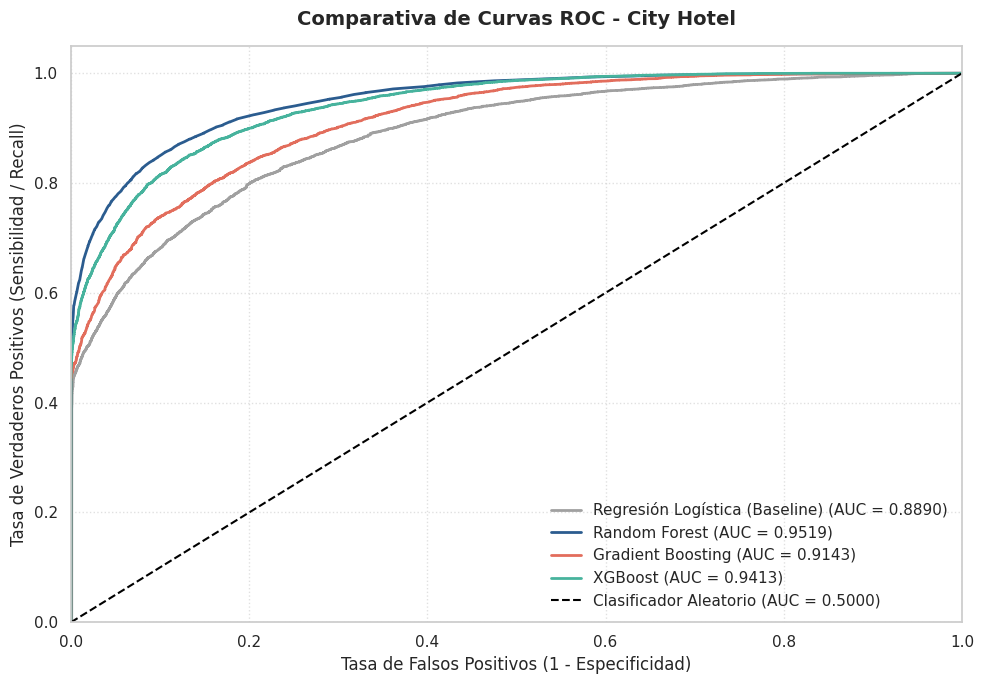


[INFO] Gráfica de curvas ROC guardada con éxito como 'curvas_roc_city.png'


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time

print("=== APRENDIZAJE SUPERVISADO - CITY HOTEL ===")

# 1. Estandarización exclusiva para el City Hotel
scaler_cit = StandardScaler()
X_train_cit_scaled = scaler_cit.fit_transform(X_train_cit_smote)
X_test_cit_scaled = scaler_cit.transform(X_test_cit)

# 2. Definición de los Modelos Expertos en City Hotel
modelos_city = {
    "Regresión Logística (Baseline)": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

resultados_city = {}

plt.figure(figsize=(10, 7))
colores = {
    "Regresión Logística (Baseline)": "#A0A0A0",
    "Random Forest": "#2b5c8f",
    "Gradient Boosting": "#e26d5c",
    "XGBoost": "#47b39d"
}

for nombre, modelo in modelos_city.items():
    print("\n" + "="*60)
    print(f"Entrenando modelo para CITY HOTEL: {nombre}...")
    start_time = time.time()

    # Entrenamiento con datos SMOTE
    modelo.fit(X_train_cit_scaled, y_train_cit_smote)
    tiempo_ent = time.time() - start_time
    print(f"Tiempo de entrenamiento: {tiempo_ent:.2f} segundos")

    # Predicción con datos de Test
    y_pred = modelo.predict(X_test_cit_scaled)
    y_pred_proba = modelo.predict_proba(X_test_cit_scaled)[:, 1]

    # Cálculo de métricas globales
    roc_auc = roc_auc_score(y_test_cit, y_pred_proba)
    resultados_city[nombre] = {
        "ROC_AUC": roc_auc,
        "Reporte": classification_report(y_test_cit, y_pred, output_dict=True)
    }

    # Calcular la curva ROC
    fpr, tpr, _ = roc_curve(y_test_cit, y_pred_proba)

    # Añadir la línea del modelo actual a la gráfica
    plt.plot(fpr, tpr, color=colores[nombre], lw=2,
             label=f'{nombre} (AUC = {roc_auc:.4f})')

    print(f"\n--- Resultados Finales - {nombre} ---")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print("\nReporte de Clasificación en Datos de Prueba Reales:")
    print(classification_report(y_test_cit, y_pred, target_names=['Confirmada (0)', 'Cancelada (1)']))

print("\n" + "="*60)
print("=== RESUMEN COMPARATIVO CITY HOTEL (ROC AUC) ===")
for m_name, metrics in resultados_city.items():
    print(f"{m_name}: {metrics['ROC_AUC']:.4f}")

plt.plot([0, 1], [0, 1], color='black', lw=1.5, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)', fontsize=12)
plt.title('Comparativa de Curvas ROC - City Hotel', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig('curvas_roc_city.png', dpi=300)
plt.show()
print("\n[INFO] Gráfica de curvas ROC guardada con éxito como 'curvas_roc_city.png'")

# Optimización de parametros

## Resort Hotel

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

print("=== OPTIMIZACIÓN HÍBRIDA Y DIAGNÓSTICO FINALES ===")

print("\n" + "="*60 + "\n[1/4] TUNING HÍBRIDO: XGBOOST (RESORT HOTEL)")

# Paso 1: Barrido Amplio Aleatorio
param_dist_xgb = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0]
}

print("-> Ejecutando Fase Estocástica (RandomizedSearchCV)...")
start_time = time.time()
xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_distributions=param_dist_xgb,
    n_iter=5, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1
)
xgb_random.fit(X_train_res_scaled, y_train_res_smote)
print(f"   Mejores parámetros preliminares (Random): {xgb_random.best_params_}")


# Paso 2: Ajuste Fino en Cuadrícula (Fine Grid Search)
# Creamos un entorno cerrado alrededor de los mejores valores encontrados

best_r_xgb = xgb_random.best_params_
param_grid_xgb = {
    'n_estimators': [best_r_xgb['n_estimators']],
    'max_depth': [best_r_xgb['max_depth'] - 1, best_r_xgb['max_depth'], best_r_xgb['max_depth'] + 1],
    'learning_rate': [best_r_xgb['learning_rate'] * 0.8, best_r_xgb['learning_rate'], best_r_xgb['learning_rate'] * 1.2],
    'subsample': [best_r_xgb['subsample']]
}

print("-> Ejecutando Fase Determinista de Ajuste Fino (GridSearchCV)...")
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=param_grid_xgb,
    cv=3, scoring='roc_auc', n_jobs=-1
)
xgb_grid.fit(X_train_res_scaled, y_train_res_smote)
best_xgb_final = xgb_grid.best_estimator_
print(f"-> HIperparámetros DEFINITIVOS XGBoost: {xgb_grid.best_params_}")
print(f"-> Tiempo total Tuning XGBoost: {time.time() - start_time:.2f} segundos")


=== OPTIMIZACIÓN HÍBRIDA Y DIAGNÓSTICO FINALES ===

[1/4] TUNING HÍBRIDO: XGBOOST (RESORT HOTEL)
-> Ejecutando Fase Estocástica (RandomizedSearchCV)...
   Mejores parámetros preliminares (Random): {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.1}
-> Ejecutando Fase Determinista de Ajuste Fino (GridSearchCV)...
-> HIperparámetros DEFINITIVOS XGBoost: {'learning_rate': 0.12, 'max_depth': 10, 'n_estimators': 300, 'subsample': 1.0}
-> Tiempo total Tuning XGBoost: 149.83 segundos


## City Hotel

In [25]:
print("\n" + "="*60 + "\n[2/4] TUNING HÍBRIDO: RANDOM FOREST (CITY HOTEL)")

# Paso 1: Barrido Amplio Aleatorio
param_dist_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("-> Ejecutando Fase Estocástica (RandomizedSearchCV)...")
start_time = time.time()
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=5, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1
)
rf_random.fit(X_train_cit_scaled, y_train_cit_smote)
print(f"   Mejores parámetros preliminares (Random): {rf_random.best_params_}")

# Paso 2: Ajuste Fino en Cuadrícula (Fine Grid Search)
# Creamos un entorno cerrado alrededor de los mejores valores encontrados
best_r_rf = rf_random.best_params_
depth_range = [best_r_rf['max_depth'] - 3, best_r_rf['max_depth'], best_r_rf['max_depth'] + 3] if best_r_rf['max_depth'] is not None else [15, 25, None]

param_grid_rf = {
    'n_estimators': [best_r_rf['n_estimators']],
    'max_depth': depth_range,
    'min_samples_split': [best_r_rf['min_samples_split']],
    'min_samples_leaf': [best_r_rf['min_samples_leaf']]
}

print("-> Ejecutando Fase Determinista de Ajuste Fino (GridSearchCV)...")
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=3, scoring='roc_auc', n_jobs=-1
)
rf_grid.fit(X_train_cit_scaled, y_train_cit_smote)
best_rf_final = rf_grid.best_estimator_
print(f"-> Hiperparámetros DEFINITIVOS Random Forest: {rf_grid.best_params_}")
print(f"-> Tiempo total Tuning Random Forest: {time.time() - start_time:.2f} segundos")




[2/4] TUNING HÍBRIDO: RANDOM FOREST (CITY HOTEL)
-> Ejecutando Fase Estocástica (RandomizedSearchCV)...
   Mejores parámetros preliminares (Random): {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
-> Ejecutando Fase Determinista de Ajuste Fino (GridSearchCV)...
-> Hiperparámetros DEFINITIVOS Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
-> Tiempo total Tuning Random Forest: 375.74 segundos


## Resultados y gráficas


[3/4] GENERANDO REPORTES Y DIAGNÓSTICOS FINALES OPTIMIZADOS

REPORTE FINAL MAESTRO: RESORT HOTEL (XGBoost Optimizado)
              precision    recall  f1-score   support

  Confirmada       0.94      0.93      0.93      8567
   Cancelada       0.82      0.84      0.83      3333

    accuracy                           0.90     11900
   macro avg       0.88      0.88      0.88     11900
weighted avg       0.91      0.90      0.91     11900


REPORTE FINAL MAESTRO: CITY HOTEL (Random Forest Optimizado)
              precision    recall  f1-score   support

  Confirmada       0.88      0.92      0.90     13750
   Cancelada       0.88      0.82      0.85      9920

    accuracy                           0.88     23670
   macro avg       0.88      0.87      0.88     23670
weighted avg       0.88      0.88      0.88     23670


[4/4] Renderizando Matrices de Confusión y Curvas ROC Definitivas...


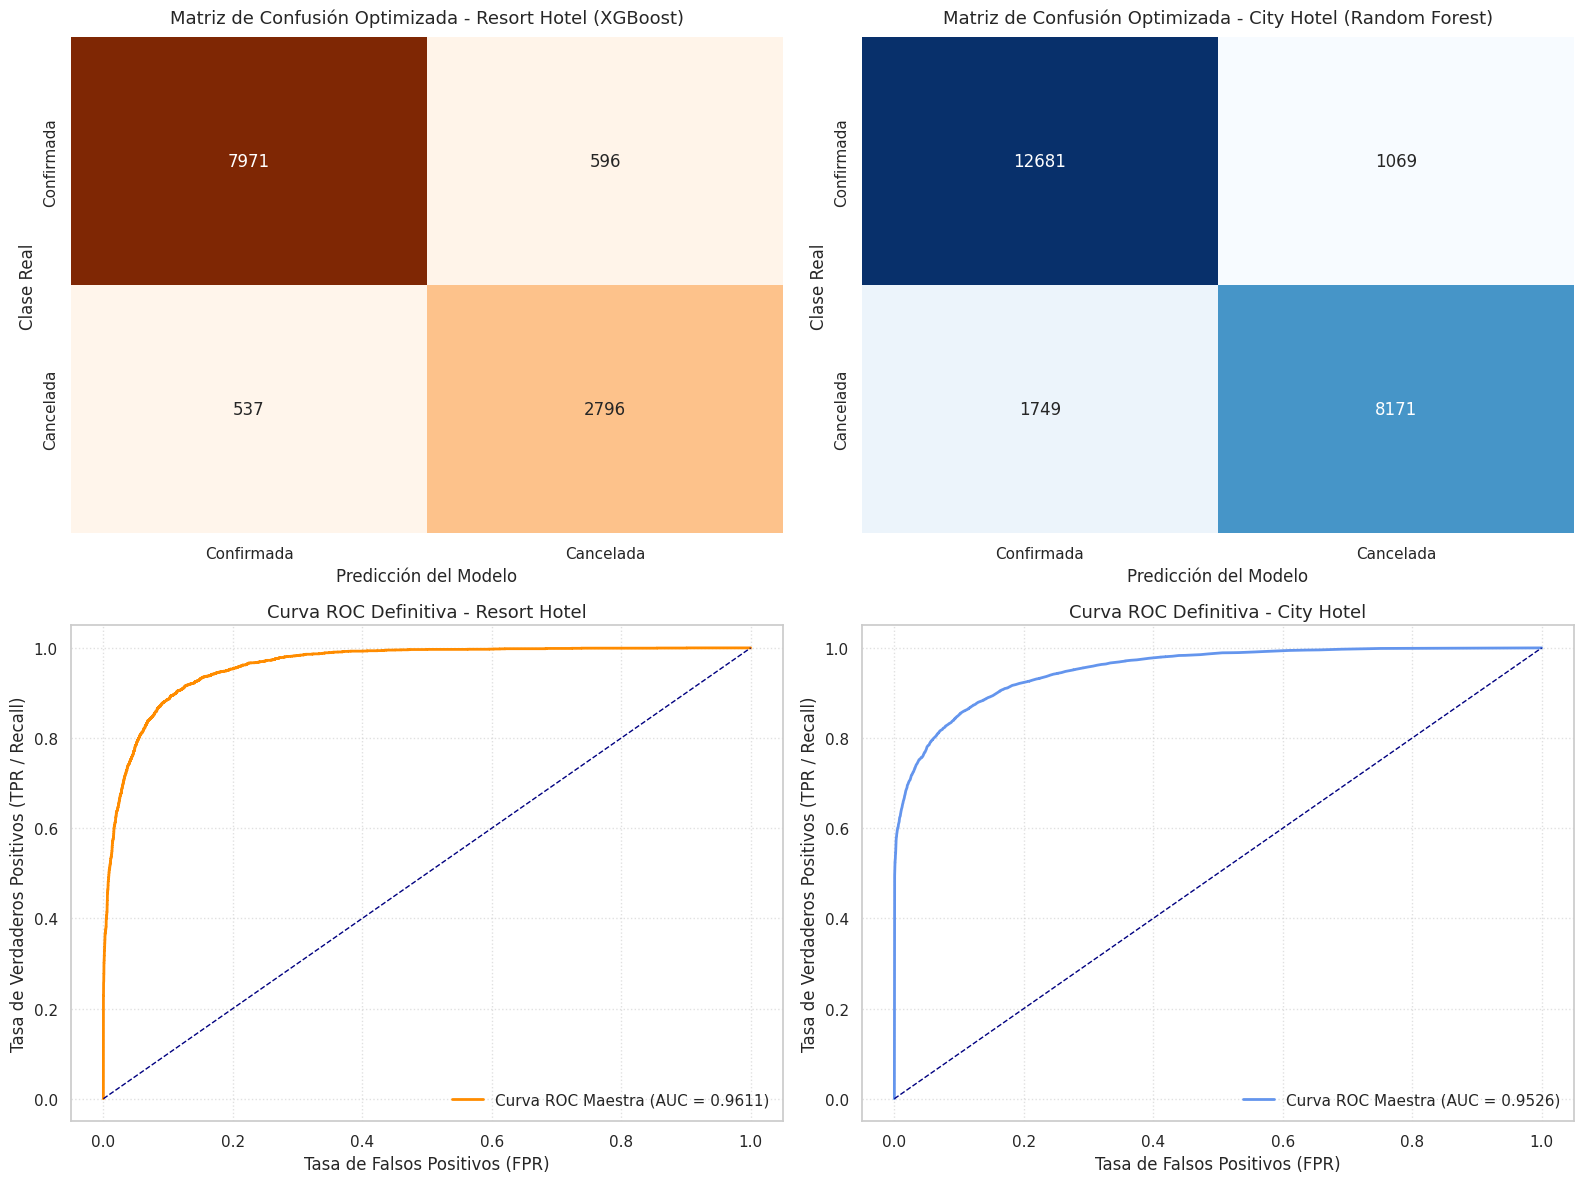

In [26]:
print("\n" + "="*60 + "\n[3/4] GENERANDO REPORTES Y DIAGNÓSTICOS FINALES OPTIMIZADOS")

# Predicciones utilizando los mejores modelos de la cuadrícula
y_pred_res = best_xgb_final.predict(X_test_res_scaled)
y_prob_res = best_xgb_final.predict_proba(X_test_res_scaled)[:, 1]

y_pred_cit = best_rf_final.predict(X_test_cit_scaled)
y_prob_cit = best_rf_final.predict_proba(X_test_cit_scaled)[:, 1]

print("\nREPORTE FINAL MAESTRO: RESORT HOTEL (XGBoost Optimizado)")
print(classification_report(y_test_res, y_pred_res, target_names=['Confirmada', 'Cancelada']))

print("\nREPORTE FINAL MAESTRO: CITY HOTEL (Random Forest Optimizado)")
print(classification_report(y_test_cit, y_pred_cit, target_names=['Confirmada', 'Cancelada']))


# VISUALIZACIÓN DE RESULTADOS FINALES
print("\n[4/4] Renderizando Matrices de Confusión y Curvas ROC Definitivas...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Matriz de Confusión Resort
cm_res = confusion_matrix(y_test_res, y_pred_res)
sns.heatmap(cm_res, annot=True, fmt='d', cmap='Oranges', ax=axes[0,0], cbar=False)
axes[0,0].set_title('Matriz de Confusión Optimizada - Resort Hotel (XGBoost)', fontsize=13, pad=10)
axes[0,0].set_xlabel('Predicción del Modelo')
axes[0,0].set_ylabel('Clase Real')
axes[0,0].set_xticklabels(['Confirmada', 'Cancelada'])
axes[0,0].set_yticklabels(['Confirmada', 'Cancelada'])

# Matriz de Confusión City
cm_cit = confusion_matrix(y_test_cit, y_pred_cit)
sns.heatmap(cm_cit, annot=True, fmt='d', cmap='Blues', ax=axes[0,1], cbar=False)
axes[0,1].set_title('Matriz de Confusión Optimizada - City Hotel (Random Forest)', fontsize=13, pad=10)
axes[0,1].set_xlabel('Predicción del Modelo')
axes[0,1].set_ylabel('Clase Real')
axes[0,1].set_xticklabels(['Confirmada', 'Cancelada'])
axes[0,1].set_yticklabels(['Confirmada', 'Cancelada'])

# Curva ROC Resort
fpr_res, tpr_res, _ = roc_curve(y_test_res, y_prob_res)
roc_auc_res = auc(fpr_res, tpr_res)
axes[1,0].plot(fpr_res, tpr_res, color='darkorange', lw=2, label=f'Curva ROC Maestra (AUC = {roc_auc_res:.4f})')
axes[1,0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[1,0].set_title('Curva ROC Definitiva - Resort Hotel', fontsize=13)
axes[1,0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1,0].set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
axes[1,0].legend(loc="lower right")
axes[1,0].grid(True, linestyle=':', alpha=0.6)

# Curva ROC City
fpr_cit, tpr_cit, _ = roc_curve(y_test_cit, y_prob_cit)
roc_auc_cit = auc(fpr_cit, tpr_cit)
axes[1,1].plot(fpr_cit, tpr_cit, color='cornflowerblue', lw=2, label=f'Curva ROC Maestra (AUC = {roc_auc_cit:.4f})')
axes[1,1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[1,1].set_title('Curva ROC Definitiva - City Hotel', fontsize=13)
axes[1,1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1,1].set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
axes[1,1].legend(loc="lower right")
axes[1,1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# FEATURE IMPORTANCE

=== FASE 5.2.C: INTERPRETABILIDAD DEL MODELO (FEATURE IMPORTANCE) ===


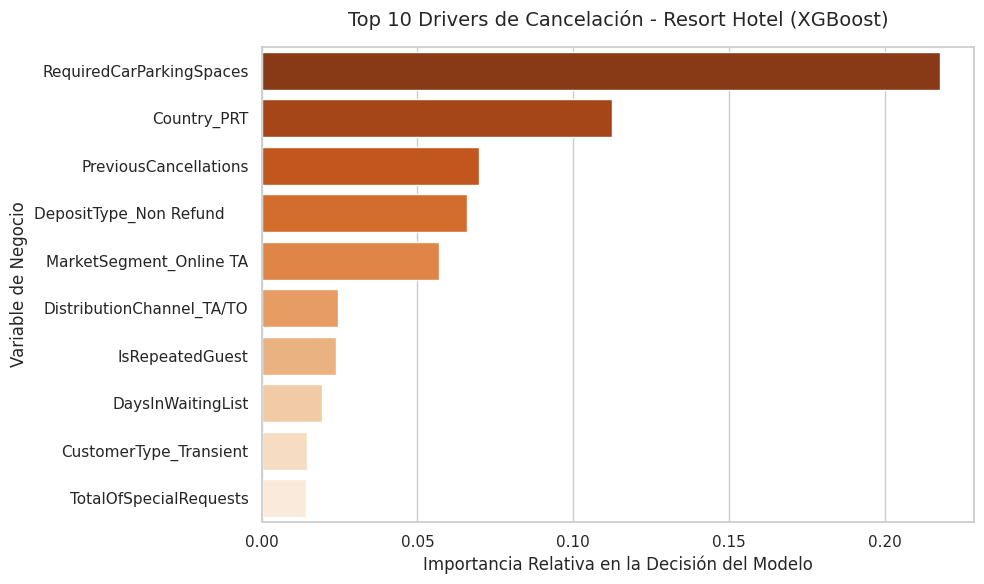

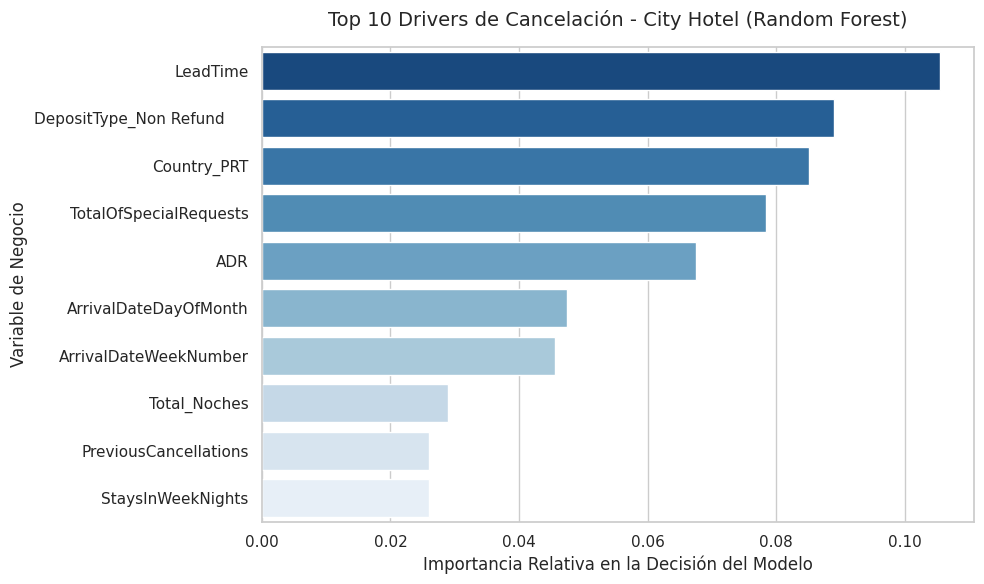

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=== FASE 5.2.C: INTERPRETABILIDAD DEL MODELO (FEATURE IMPORTANCE) ===")

modelo_ganador_resort = modelos_resort["XGBoost"]
modelo_ganador_city = modelos_city["Random Forest"]

# Calcular y graficar el Top 10 de variables
def graficar_importancia(modelo, nombres_columnas, titulo, paleta):
    importancias = modelo.feature_importances_

    df_importancia = pd.DataFrame({
        'Variable': nombres_columnas,
        'Importancia': importancias
    })
    df_top10 = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importancia', y='Variable', data=df_top10, palette=paleta)
    plt.title(f'Top 10 Drivers de Cancelación - {titulo}', fontsize=14, pad=15)
    plt.xlabel('Importancia Relativa en la Decisión del Modelo', fontsize=12)
    plt.ylabel('Variable de Negocio', fontsize=12)
    plt.tight_layout()
    plt.show()

# Generar los gráficos (Pasamos las columnas de X_resort y X_city originales)
graficar_importancia(best_xgb_final, X_resort.columns, "Resort Hotel (XGBoost)", "Oranges_r")
graficar_importancia(best_rf_final, X_city.columns, "City Hotel (Random Forest)", "Blues_r")